# Dataset Exploration for Named Entity Recognition (IOB2)

Before building any models, I analyse the CoNLL-2003 dataset to understand its structural and statistical properties.


Specifically, I examine:

- **Label imbalance: The "O" Problem**   
    How dominant is the "O" class compared to entity labels? This affects evaluation metrics and model bias.

- **Sentence length distribution**    
    Are the sentences mostly long news articles or short fragments? This informs padding strategy and maximum sequence length for the BiLSTM.
    
- **Surface cues**  
    Do entities typically start with capital letters or contain specific character patterns? These signals guide feature engineering for the Logistic Regression baseline.

- **Multi-token entity spans**  
    How often do we observe multi-token entities? This helps estimate the importance of sequence modelling.
    
- **Vocabulary coverage and OOV (Out-of-Vocabulary) issues**  
    How large is the vocabulary, and how often do unseen words appear in validation/test splits? This informs embedding and generalisation strategies.

## Objective

The goal is to derive modelling hypotheses that will inform:

- Feature design for the Logistic Regression baseline
- Architectural choices for the BiLSTM sequence model

This notebook follows a data-first, hypothesis-driven approach.

In [ ]:
%cd /content/drive/MyDrive/projects/ner-comparison-project/

/content/drive/MyDrive/projects/ner-comparison-project


In [ ]:
# Creating the folders in Repository Structure
import os

folders = ["data/raw", "data/processed", "src", "models", "results", "notebooks"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

Download the CoNLL003 (English-version) dataset

In [ ]:
# Create kaggle connection
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efemirkan","key":"374cc44929371121bc09ffedd7711d89"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the CoNLL003 (English-version) dataset
!kaggle datasets download -d alaakhaled/conll003-englishversion -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/alaakhaled/conll003-englishversion
License(s): CC0-1.0
  0% 0.00/960k [00:00<?, ?B/s]
100% 960k/960k [00:00<00:00, 56.3MB/s]


Create GitHub connection and push the 00_data_exploration.ipynb notebook

In [ ]:
!git add .
!git commit -m "Add data exploration notebook for NER"


On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (10/10), 961.23 KiB | 3.21 MiB/s, done.
Total 10 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), done.
To https://github.com//Efemirkan/ner-comparison-project.git
   448eb08..43f2d9c  main -> main


In [ ]:
!git remote -v

origin	https://github.com/Efemirkan/ner-comparison-project.git (fetch)
origin	https://github.com/Efemirkan/ner-comparison-project.git (push)


In [ ]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [ ]:
!git push -u origin main

Branch 'main' set up to track remote branch 'main' from 'origin'.
Everything up-to-date


### **1- Load the Dataset**

In [ ]:
!git pull

remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 17 (delta 2), reused 17 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (17/17), 2.46 KiB | 7.00 KiB/s, done.
From https://github.com//Efemirkan/ner-comparison-project
   43f2d9c..e2a3a52  main       -> origin/main
Updating 43f2d9c..e2a3a52
Fast-forward
 .idea/.gitignore                               | 10 +++++++
 .idea/inspectionProfiles/profiles_settings.xml |  6 +++++
 .idea/misc.xml                                 |  7 +++++
 .idea/modules.xml                              |  8 ++++++
 .idea/ner-comparison-project.iml               | 10 +++++++
 .idea/vcs.xml                                  |  6 +++++
 src/__init__.py                                |  0
 src/load_dataset.py                            | 36 ++++++++++++++++++++++++++
 8 files changed, 83 insertions(+)
 create mode 100644 .idea/.gitignore
 create mode 100644 .ide

In [5]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [7]:
from src.load_dataset import load_dataset

train_sents, train_tags = load_dataset("../data/raw/train.txt")
valid_sents, valid_tags = load_dataset("../data/raw/valid.txt")
test_sents, test_tags = load_dataset("../data/raw/test.txt")

In [8]:
print(f"Training sentences: {len(train_sents)}")
print(f"Testing tags: {len(test_tags)}")

Training sentences: 14041
Testing tags: 3453


In [9]:
print(train_sents[:5])
print(valid_tags[:5])
print(test_sents[:5])

[['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], ['Peter', 'Blackburn'], ['BRUSSELS', '1996-08-22'], ['The', 'European', 'Commission', 'said', 'on', 'Thursday', 'it', 'disagreed', 'with', 'German', 'advice', 'to', 'consumers', 'to', 'shun', 'British', 'lamb', 'until', 'scientists', 'determine', 'whether', 'mad', 'cow', 'disease', 'can', 'be', 'transmitted', 'to', 'sheep', '.'], ['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']]
[['O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'], ['B-LOC', 'O'], ['B-MISC', 'I-MISC', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'],

In [10]:
# Sanity Check
for s, t in zip(train_sents[:10], train_tags[:10]):
    assert len(s) == len(t)
print(f"Words and tags matched")

Words and tags matched


I can confirm that datasets align accurately.

### **2- Basic Statistics**

- **How big is the dataset?** Dataset size affects model capacity.
- **How long are the sentences?** Sentence length affect padding strategy.
- **Is the data structually consistent? Are tokens aligned with tags?** Misalignent bugs destroy training step.


In [ ]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 359 bytes | 3.00 KiB/s, done.
From https://github.com//Efemirkan/ner-comparison-project
   2ead29d..c270e35  main       -> origin/main
Updating 2ead29d..c270e35
Fast-forward
 src/basic_stats.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [11]:
from src.basic_stats import dataset_stats, sent_length_distribution, check_sanity

In [12]:
print("Training Set Stats:")
dataset_stats(train_sents, train_tags)
print("-")
print("Validation Set Stats:")
dataset_stats(valid_sents, valid_tags)
print("-")
print("Test Set Stats:")
dataset_stats(test_sents, test_tags)

Training Set Stats:
Number of sentences: 14041
Number of tokens: 203621
Number of tags: 14041
Average sentence length: 14.501887329962253
-
Validation Set Stats:
Number of sentences: 3250
Number of tokens: 51362
Number of tags: 3250
Average sentence length: 15.803692307692307
-
Test Set Stats:
Number of sentences: 3453
Number of tokens: 46435
Number of tags: 3453
Average sentence length: 13.447726614538082


I have ~14k sentences and ~200k tokens in the training set. This means the model is exposed to many labeled entity instances as well as diverse surrounding word contexts, allowing it to learn both what entities look like and when they occur. Therefore, the dataset is large enough for a BiLSTM to learn meaningful patterns. At the same time, ~200k tokens per epoch is relatively small, so the model can train quickly.

The average sentence length is 13-16 tokens. Since the computational cost of an LSTM gros with sequence length, shorter sentences require less memory and computation. This results in faster training and efficient batching. Therefore, the dataset is friendly for sequence models such as BiLSTM.

The training, validation and test sets have similar average sentence lengths. This suggests that there is no major distribution shift between splits. Thus, evaluation results on the validation and test sets are likely to reflect true model generalisation.

In [13]:
print(f"Avg. sentence length in training set:")
sent_length_distribution(train_sents)
print("-")
print(f"Avg. sentence length in validation set:")
sent_length_distribution(valid_sents)
print("-")
print(f"Avg. sentence length in testing set:")
sent_length_distribution(test_sents)

Avg. sentence length in training set:
Median length: 10.0
95th percentile: 37.0
Max length: 113
-
Avg. sentence length in validation set:
Median length: 11.0
95th percentile: 39.0
Max length: 109
-
Avg. sentence length in testing set:
Median length: 9.0
95th percentile: 37.0
Max length: 124


The median sentence length is 9-11 tokens, incdicating that most sentences are relatively short.

The 95th percentile is around 37-39 token, suggesting that long sentence are rare, only last 5% exceed these lengths.

Although the maximum sentence length exceeds 100 tokens, these cases are outliers.

THerefore, dynamic padding or a maximum sequence length 40 tokens would be efficient for the BiLSTM model.

In [14]:
print("In Training set")
check_sanity(train_sents, train_tags)
print("-")
print("In Validation set")
check_sanity(valid_sents, valid_tags)
print("-")
print("In Testing set")
check_sanity(test_sents, test_tags)

In Training set
Tokens and tags matched
-
In Validation set
Tokens and tags matched
-
In Testing set
Tokens and tags matched


Token and label alignment checks passed for all sets. This confirms that each token is associated with exactly one tag.

Therefore, the dataset is consistent and safe for sequence modelling.

### **3- Tag Distribution**

In [ ]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 696 bytes | 6.00 KiB/s, done.
From https://github.com//Efemirkan/ner-comparison-project
   b1f4f2f..3107c98  main       -> origin/main
Updating b1f4f2f..3107c98
Fast-forward
 src/basic_stats.py | 31 +++++++++++++++++++++++++++----
 1 file changed, 27 insertions(+), 4 deletions(-)


In [15]:
# Reload basic_stats.py
import importlib, src.basic_stats
importlib.reload(src.basic_stats)

<module 'src.basic_stats' from 'd:\\AI\\repos\\ner-comparison-project\\src\\basic_stats.py'>

In [16]:
from src.basic_stats import tag_distribution

train_tag_counts, train_tag_count_perc = tag_distribution(train_tags)
valid_tag_counts, valid_tag_count_perc = tag_distribution(valid_tags)
test_tag_counts, test_tag_count_perc = tag_distribution(test_tags)

In [17]:
print("Training set tag distribution by percentage")
print(train_tag_count_perc)
print("-")
print("Validation set tag distribution by percentage")
print(valid_tag_count_perc)
print("-")
print("Testing set tag distribution by percentage")
print(test_tag_count_perc)

Training set tag distribution by percentage
{'B-LOC': 3.51, 'B-MISC': 1.69, 'B-ORG': 3.1, 'B-PER': 3.24, 'I-LOC': 0.57, 'I-MISC': 0.57, 'I-ORG': 1.82, 'I-PER': 2.22, 'O': 83.28}
-
Validation set tag distribution by percentage
{'B-LOC': 3.58, 'B-MISC': 1.8, 'B-ORG': 2.61, 'B-PER': 3.59, 'I-LOC': 0.5, 'I-MISC': 0.67, 'I-ORG': 1.46, 'I-PER': 2.54, 'O': 83.25}
-
Testing set tag distribution by percentage
{'B-LOC': 3.59, 'B-MISC': 1.51, 'B-ORG': 3.58, 'B-PER': 3.48, 'I-LOC': 0.55, 'I-MISC': 0.47, 'I-ORG': 1.8, 'I-PER': 2.49, 'O': 82.53}


<Axes: >

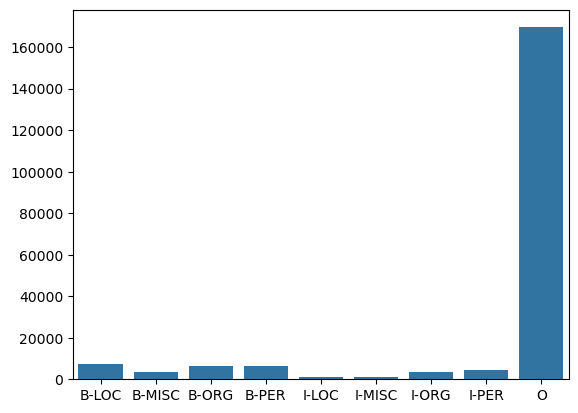

In [18]:
import seaborn as sns


sns.barplot(train_tag_counts, x=list(train_tag_counts.keys()), y=list(train_tag_counts.values()))

Text(0.5, 1.0, 'Train, Valid, Test Datasets Tag Distributions')

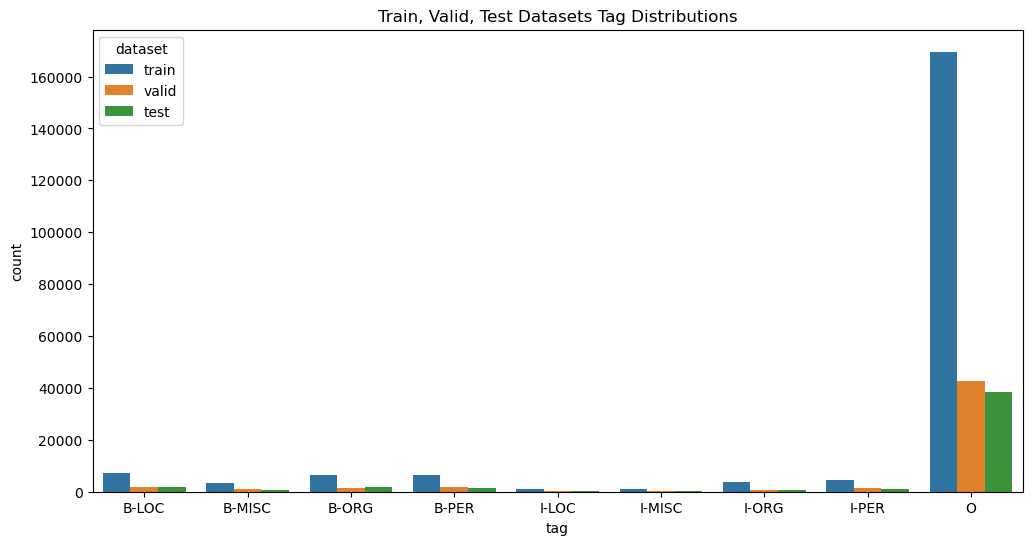

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert counters to DataFrames
train_tag_df = pd.DataFrame({"tag": train_tag_counts.keys(), "count": train_tag_counts.values(), "dataset": "train"})

valid_tag_df = pd.DataFrame({"tag": valid_tag_counts.keys(), "count": valid_tag_counts.values(), "dataset": "valid"})

test_tag_df = pd.DataFrame({"tag": test_tag_counts.keys(), "count": test_tag_counts.values(), "dataset": "test"})

# Merge all
all_tag_df = pd.concat([train_tag_df, valid_tag_df, test_tag_df])

plt.figure(figsize=(12,6))
sns.barplot(all_tag_df, x="tag", y="count",hue="dataset")
plt.title("Train, Valid, Test Datasets Tag Distributions")

Text(0.5, 1.0, "Train, Valid, Test Datasets Tag Distributions without 'O'")

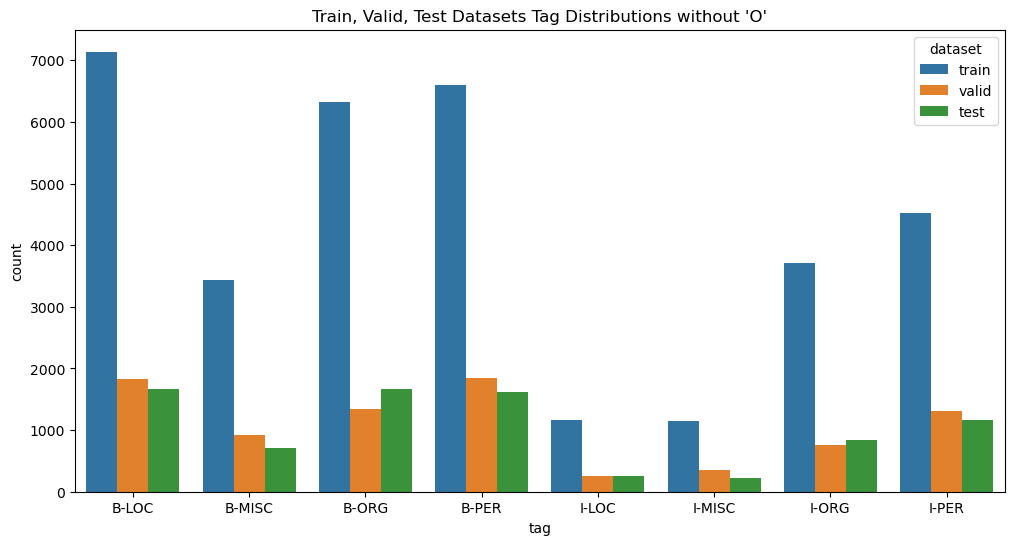

In [21]:
# Plot without "O"
removed_o_df = all_tag_df[all_tag_df["tag"] != "O"]

plt.figure(figsize=(12,6))
sns.barplot(removed_o_df, x="tag", y="count",hue="dataset")
plt.title("Train, Valid, Test Datasets Tag Distributions without 'O'")

I observe that the dataset splits exhibits strong class imbalance, with the "O" tag representing around 82-83% of all tokens. This makes token level accuracy misleading and motivates me to use of entity level F1 as the primary evaluation metric.

I also observe that the tag distributions is high consistent across training, validation and test sets, indicating no significant distribution shift.

Furthermore, I notice that B-tags are generally more frequent than I-tags, suggesting that many entities consist of single token. Additionally, the MISC category appears less frequent then PER, ORG and LOC which may affect per class performance.

### **4- Entity Distribution**

In [ ]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 404 bytes | 4.00 KiB/s, done.
From https://github.com//Efemirkan/ner-comparison-project
   3107c98..3caeeef  main       -> origin/main
Updating 3107c98..3caeeef
Fast-forward
 src/basic_stats.py | 3 +++
 1 file changed, 3 insertions(+)


In [22]:
from itertools import zip_longest
from src.basic_stats import entity_distribution

train_entity_counts, train_no_o_counts = entity_distribution(train_tags)
valid_entity_counts, valid_no_o_counts = entity_distribution(valid_tags)
test_entity_counts, test_no_o_counts = entity_distribution(test_tags)

In [23]:
cols = pd.MultiIndex.from_product([['Counts'], ["Training Set", "Validation Set", "Testing Set"]])

df_entity = pd.DataFrame(list(zip_longest(train_entity_counts.values(), valid_entity_counts.values(), test_entity_counts.values())),
                         columns=cols, index=train_entity_counts.keys())



df_entity

Counts                           
     Training Set Validation Set Testing Set
LOC          8297           2094        1925
MISC         4593           1268         918
O          169578          42759       38323
ORG         10025           2092        2496
PER         11128           3149        2773

Text(0.5, 1.0, "Train, Valid, Test Datasets Entity Distributions without 'O'")

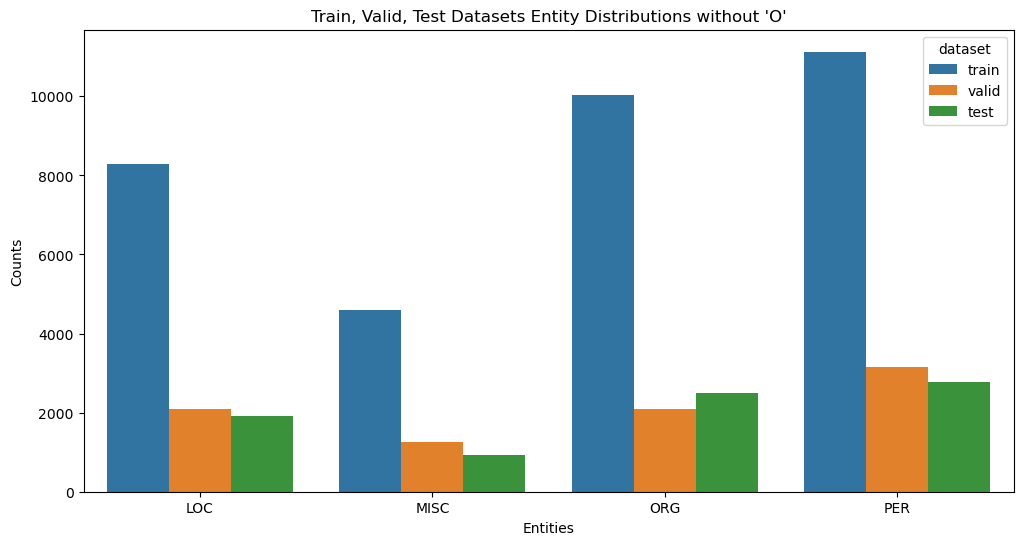

In [24]:
# Convert counters to DataFrames
train_entity_df = pd.DataFrame({"entity": train_no_o_counts.keys(), "count": train_no_o_counts.values(), "dataset": "train"})

valid_entity_df = pd.DataFrame({"entity": valid_no_o_counts.keys(), "count": valid_no_o_counts.values(), "dataset": "valid"})

test_entity_df = pd.DataFrame({"entity": test_no_o_counts.keys(), "count": test_no_o_counts.values(), "dataset": "test"})

# Merge all
all_entity_df = pd.concat([train_entity_df, valid_entity_df, test_entity_df])

plt.figure(figsize=(12,6))
sns.barplot(all_entity_df, x="entity", y="count",hue="dataset")
plt.xlabel("Entities")
plt.ylabel("Counts")
plt.title("Train, Valid, Test Datasets Entity Distributions without 'O'")

After collapsing the BIO tags into entity types, I observe that PER is the most frequent entity class, followed closely by ORG and LOC, while MISC is the least frequent across all splits. The relative distribution of entity types is very similar between the training, validation, and test sets, which suggests that there is no significant distribution shift in terms of entity categories.

Although the dataset is highly imbalanced at the token level due to the dominance of the O tag, the distribution among the actual entity types is relatively balanced.

### **4- Surface Cues**